# 10 — Advanced EDA Blocco 6: Analisi Geospaziale

**Fase PACE**: Analyze (avanzata)  
**Obiettivo**: identificare hotspot geografici della criminalità a Los Angeles, 
misurarne la persistenza nel tempo e validarli statisticamente attraverso 
indici di autocorrelazione spaziale.

**Input**: `data/processed/crimes_features.parquet`

**Domande a cui rispondiamo**:
- Q6.1 — Mappa hotspot su griglia 500m × 500m
- Q6.2 — Persistenza degli hotspot nel tempo
- Q6.3 — Clustering spaziale statistico (Moran's I, Getis-Ord Gi*)

**Strumenti utilizzati e motivazione**:
- **geopandas**: gestione e manipolazione di dati geospaziali (geometrie, 
  sistemi di coordinate, operazioni spaziali)
- **folium**: visualizzazione di mappe interattive basate su Leaflet.js
- **shapely**: creazione e manipolazione di geometrie (punti, griglie, poligoni)
- **PySAL** (in particolare i moduli `esda` e `libpysal`): libreria di 
  riferimento per l'analisi spaziale statistica in Python. Utilizzata per 
  calcolare Moran's I (autocorrelazione spaziale globale) e Getis-Ord Gi* 
  (identificazione di hotspot/coldspot locali)

**Nota metodologica**: le coordinate LAT/LON nel dataset sono spesso 
offuscate al centroide del blocco (~100m di precisione), come documentato 
nelle limitazioni del progetto. Questo va tenuto presente nell'interpretazione 
dei risultati a grana fine.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import geopandas as gpd
from shapely.geometry import Point, Polygon
import folium

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_info_columns', 200)

df = pd.read_parquet('../../data/processed/crimes_features.parquet')
df.head()

,DR_NO,Date Rptd,DATE OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Mocodes,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Weapon Used Cd,Weapon Desc,Status,Status Desc,Crm Cd 1,LOCATION,LAT,LON,hour_occ,year,month,day_of_week,hour_bins,age_group,crime_category,report_delay,is_domestic
0,1307355,2010-02-20,2010-02-20,13,Newton,1385,2,900,VIOLATION OF COURT ORDER,0913 1814 2000,48.0,M,H,501.0,SINGLE FAMILY DWELLING,0.0,No Weapon,AA,Adult Arrest,900.0,300 E GAGE AV,33.9825,-118.2695,13,2010,2,Saturday,Afternoon,Adult,person,0,False
1,11401303,2010-09-13,2010-09-12,14,Pacific,1485,2,740,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",0329,NaN,M,W,101.0,STREET,0.0,No Weapon,IC,Invest Cont,740.0,SEPULVEDA BL,33.9599,-118.3962,0,2010,9,Sunday,Night,NaN,property,1,False
2,70309629,2010-08-09,2010-08-09,13,Newton,1324,2,946,OTHER MISCELLANEOUS CRIME,0344,NaN,M,H,103.0,ALLEY,0.0,No Weapon,IC,Invest Cont,946.0,1300 E 21ST ST,34.0224,-118.2524,15,2010,8,Monday,Afternoon,NaN,other,0,False
3,90631215,2010-01-05,2010-01-05,6,Hollywood,646,2,900,VIOLATION OF COURT ORDER,1100 0400 1402,47.0,F,W,101.0,STREET,102.0,HAND GUN,IC,Invest Cont,900.0,CAHUENGA BL,34.1016,-118.3295,1,2010,1,Tuesday,Night,Adult,person,0,False
4,100100501,2010-01-03,2010-01-02,1,Central,176,1,122,"RAPE, ATTEMPTED",0400,47.0,F,H,103.0,ALLEY,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,122.0,8TH ST,34.0387,-118.2488,21,2010,1,Saturday,Late Night,Adult,person,1,False


## 2. Q6.1 — Mappa hotspot su griglia 500m × 500m

Costruiamo una griglia regolare di celle 500m × 500m sull'area di Los Angeles 
e identifichiamo le celle che concentrano la quota maggiore di reati violenti, 
pur rappresentando una porzione minima della superficie totale.

**Obiettivo**: identificare le zone a più alta concentrazione di criminalità 
violenta con una risoluzione spaziale fine, utile per allocare risorse di 
pattugliamento in modo mirato.

**Nota preliminare**: il dataset contiene 3.148 record con coordinate 
sentinella (0,0) convertite in NaN durante il cleaning. Questi record 
verranno esclusi dall'analisi geospaziale.

In [2]:
q61_df = df.loc[df['crime_category'] == 'person', ['LAT', 'LON', 'month', 'year']].copy()

print(q61_df.head())

       LAT       LON  month  year
0  33.9825 -118.2695      2  2010
3  34.1016 -118.3295      1  2010
4  34.0387 -118.2488      1  2010
7  34.0435 -118.2427      1  2010
8  34.0450 -118.2640      1  2010


In [3]:
print(q61_df.isna().sum())
print(q61_df.shape)

LAT      1362
LON      1362
month       0
year        0
dtype: int64
(1093024, 4)


In [4]:
q61_df = q61_df.dropna()
print(q61_df.shape)

(1091662, 4)


In [5]:
geometry = gpd.points_from_xy(q61_df['LON'], q61_df['LAT'])
q61_gdf = gpd.GeoDataFrame(q61_df, geometry=geometry, crs='EPSG:4326')
print(q61_gdf.head())

       LAT       LON  month  year                   geometry
0  33.9825 -118.2695      2  2010  POINT (-118.2695 33.9825)
3  34.1016 -118.3295      1  2010  POINT (-118.3295 34.1016)
4  34.0387 -118.2488      1  2010  POINT (-118.2488 34.0387)
7  34.0435 -118.2427      1  2010  POINT (-118.2427 34.0435)
8  34.0450 -118.2640      1  2010    POINT (-118.264 34.045)


In [6]:
q61_gdf = q61_gdf.to_crs('EPSG:32611')
print(q61_gdf.head())
print(q61_gdf.total_bounds)

       LAT       LON  month  year                        geometry
0  33.9825 -118.2695      2  2010  POINT (382736.762 3760941.804)
3  34.1016 -118.3295      1  2010  POINT (377365.803 3774219.079)
4  34.0387 -118.2488      1  2010  POINT (384724.916 3767150.226)
7  34.0435 -118.2427      1  2010  POINT (385294.495 3767675.637)
8  34.0450 -118.2640      1  2010  POINT (383330.367 3767866.052)
[ 337119.687848   3690064.40020423  434393.29978211 3850623.09029826]


In [7]:
minx, miny, maxx, maxy = q61_gdf.total_bounds
print(minx, miny, maxx, maxy)

cell_size = 500  # metri

n_cols = int((maxx - minx) / cell_size) + 1
n_rows = int((maxy - miny) / cell_size) + 1

print(f'Colonne: {n_cols}, Righe: {n_rows}, Totale celle: {n_cols * n_rows}')

337119.68784799986 3690064.4002042282 434393.2997821095 3850623.090298263
Colonne: 195, Righe: 322, Totale celle: 62790


In [8]:
from shapely.geometry import box

grid_cells = []
for i in range(n_cols):
    for j in range(n_rows):
        x0 = minx + i * cell_size
        y0 = miny + j * cell_size
        x1 = x0 + cell_size
        y1 = y0 + cell_size
        grid_cells.append(box(x0, y0, x1, y1))

print(f'Celle create: {len(grid_cells)}')

Celle create: 62790


In [9]:
grid_gdf = gpd.GeoDataFrame({'geometry': grid_cells}, crs='EPSG:32611')
grid_gdf['cell_id'] = grid_gdf.index
print(grid_gdf.head())

                                            geometry  cell_id
0  POLYGON ((337619.688 3690064.4, 337619.688 369...        0
1  POLYGON ((337619.688 3690564.4, 337619.688 369...        1
2  POLYGON ((337619.688 3691064.4, 337619.688 369...        2
3  POLYGON ((337619.688 3691564.4, 337619.688 369...        3
4  POLYGON ((337619.688 3692064.4, 337619.688 369...        4


In [10]:
joined = gpd.sjoin(q61_gdf, grid_gdf, how='left', predicate='within')
print(joined.head())
print(joined.shape)

       LAT       LON  month  year                        geometry  \
0  33.9825 -118.2695      2  2010  POINT (382736.762 3760941.804)   
3  34.1016 -118.3295      1  2010  POINT (377365.803 3774219.079)   
4  34.0387 -118.2488      1  2010  POINT (384724.916 3767150.226)   
7  34.0435 -118.2427      1  2010  POINT (385294.495 3767675.637)   
8  34.0450 -118.2640      1  2010  POINT (383330.367 3767866.052)   

   index_right  cell_id  
0      29443.0  29443.0  
3      25928.0  25928.0  
4      30744.0  30744.0  
7      31067.0  31067.0  
8      29779.0  29779.0  
(1091662, 7)


In [11]:
cell_counts = joined.groupby('cell_id', as_index=False).size()
cell_counts.columns = ['cell_id', 'crime_count']
cell_counts = cell_counts.sort_values('crime_count', ascending=False)
print(cell_counts.head(10))
print(f'\nCelle con almeno 1 crimine: {len(cell_counts)}')
print(f'Celle totali nella griglia: {len(grid_gdf)}')

      cell_id  crime_count
4178  30745.0         9017
3874  29138.0         5888
4129  30423.0         5265
4224  31067.0         4930
4177  30744.0         4922
2983  25284.0         4268
4080  30102.0         3811
3039  25606.0         3642
4179  30746.0         3461
4130  30424.0         3302

Celle con almeno 1 crimine: 4706
Celle totali nella griglia: 62790


In [12]:
total_crimes = cell_counts['crime_count'].sum()
total_active_cells = len(cell_counts)

cell_counts['cumulative_pct'] = cell_counts['crime_count'].cumsum() / total_crimes * 100
cell_counts['cell_rank_pct'] = (range(1, len(cell_counts) + 1)) 
cell_counts['cell_rank_pct'] = cell_counts['cell_rank_pct'] / total_active_cells * 100

top5pct_cells = cell_counts[cell_counts['cell_rank_pct'] <= 5]
print(f'Celle nel top 5%: {len(top5pct_cells)}')
print(f'Crimini in quelle celle: {top5pct_cells["crime_count"].sum()}')
print(f'Percentuale crimini coperta: {top5pct_cells["crime_count"].sum() / total_crimes * 100:.1f}%')

Celle nel top 5%: 235
Crimini in quelle celle: 359163
Percentuale crimini coperta: 32.9%


In [13]:
top5pct_geo = grid_gdf[grid_gdf['cell_id'].isin(top5pct_cells['cell_id'])].copy()
top5pct_geo = top5pct_geo.to_crs('EPSG:4326')

m = folium.Map(location=[34.05, -118.25], zoom_start=10, tiles='CartoDB positron')

for _, row in top5pct_geo.iterrows():
    folium.GeoJson(
        row['geometry'],
        style_function=lambda x: {'fillColor': 'red', 'color': 'red', 'weight': 1, 'fillOpacity': 0.5}
    ).add_to(m)

m

m.save('../../outputs/10_advanced_eda_block1/32_hotspot_map_top5pct.html')

## 3. Q6.2 — Persistenza degli hotspot nel tempo

Misuriamo la stabilità degli hotspot calcolando il grado di sovrapposizione 
(overlap) tra gli hotspot identificati in periodi temporali consecutivi.

**Obiettivo**: distinguere tra:
- **Hotspot cronici**: celle che rimangono costantemente tra le più calde 
  nel tempo — richiedono interventi strutturali di lungo periodo
- **Hotspot emergenti**: celle che diventano calde solo in certi periodi — 
  richiedono interventi tattici e reattivi

**Metrica**: percentuale di overlap mese su mese — quante delle celle 
hotspot del mese corrente erano già hotspot il mese precedente.

In [15]:
monthly_counts = (
    joined
    .groupby(['year', 'month', 'cell_id'], as_index=False)
    .size()
    .rename(columns={'size': 'crime_count'})
)
print(monthly_counts.head(10))
print(f'Shape: {monthly_counts.shape}')

   year  month  cell_id  crime_count
0  2010      1   6633.0            1
1  2010      1   6949.0            1
2  2010      1   6950.0            1
3  2010      1   6958.0            3
4  2010      1   7267.0            1
5  2010      1   7269.0            1
6  2010      1   7273.0            1
7  2010      1   7590.0            1
8  2010      1   7593.0            1
9  2010      1   7594.0            2
Shape: (343129, 4)


In [17]:
def get_hotspot_cells(group, pct=0.05):
    n = max(1, int(len(group) * pct))
    return set(group.nlargest(n, 'crime_count')['cell_id'])

monthly_hotspots = (
    monthly_counts
    .groupby(['year', 'month'])
    .apply(get_hotspot_cells, include_groups=False)
    .reset_index()
)
monthly_hotspots.columns = ['year', 'month', 'hotspot_cells']
print(monthly_hotspots.head(5))
print(f'Mesi totali: {len(monthly_hotspots)}')

   year  month                                      hotspot_cells
0  2010      1  {30720.0, 28160.0, 25603.0, 30723.0, 25606.0, ...
1  2010      2  {25604.0, 28170.0, 28172.0, 28175.0, 28179.0, ...
2  2010      3  {28160.0, 30722.0, 25603.0, 25606.0, 28172.0, ...
3  2010      4  {30720.0, 25603.0, 25606.0, 28170.0, 28171.0, ...
4  2010      5  {30720.0, 28160.0, 28161.0, 28170.0, 28173.0, ...
Mesi totali: 180


In [18]:
overlaps = []
for i in range(1, len(monthly_hotspots)):
    current = monthly_hotspots.iloc[i]['hotspot_cells']
    previous = monthly_hotspots.iloc[i-1]['hotspot_cells']
    overlap_pct = len(current & previous) / len(current) * 100
    overlaps.append({
        'year': monthly_hotspots.iloc[i]['year'],
        'month': monthly_hotspots.iloc[i]['month'],
        'overlap_pct': overlap_pct
    })

overlap_df = pd.DataFrame(overlaps)
print(overlap_df.head(10))
print(f'\nOverlap medio: {overlap_df["overlap_pct"].mean():.1f}%')

   year  month  overlap_pct
0  2010      2    48.000000
1  2010      3    45.192308
2  2010      4    51.000000
3  2010      5    46.226415
4  2010      6    49.074074
5  2010      7    50.476190
6  2010      8    48.076923
7  2010      9    39.603960
8  2010     10    46.601942
9  2010     11    54.639175

Overlap medio: 49.4%


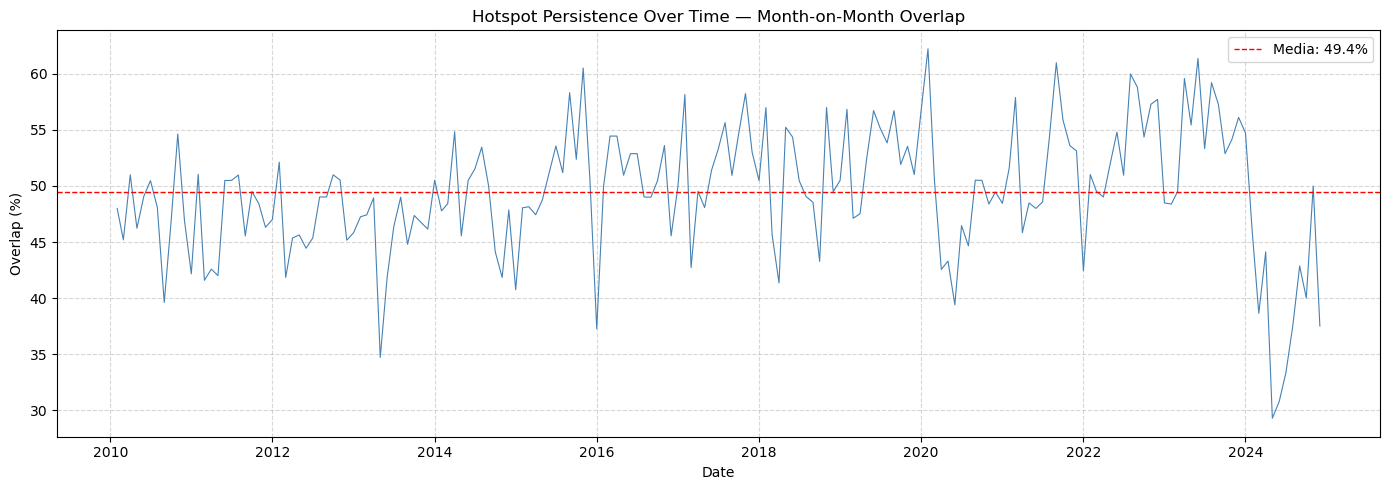

In [20]:
overlap_df['date'] = pd.to_datetime(overlap_df[['year', 'month']].assign(day=1))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(overlap_df['date'], overlap_df['overlap_pct'], linewidth=0.8, color='steelblue')
ax.axhline(y=overlap_df['overlap_pct'].mean(), color='red', linestyle='--', linewidth=1, label=f'Media: {overlap_df["overlap_pct"].mean():.1f}%')
ax.set_title('Hotspot Persistence Over Time — Month-on-Month Overlap')
ax.set_xlabel('Date')
ax.set_ylabel('Overlap (%)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../../outputs/10_advanced_eda_block1/33_hotspot_persistence.png', dpi=150, bbox_inches='tight')
plt.show()

### Osservazioni Q6.2 — Persistenza degli hotspot nel tempo

**Metrica**: percentuale di overlap mese su mese — quante celle calde del 
mese corrente erano già calde il mese precedente.

**Overlap medio: 49.4%** — circa la metà delle celle calde di ogni mese 
erano già calde il mese precedente. Questo indica che gli hotspot hanno 
una componente cronica significativa ma non dominante: non cambiano 
completamente da un mese all'altro, ma circa il 50% degli hotspot si 
rinnova ogni mese.

**Pattern temporale — due fasi distinte**:

- **2010–2015**: overlap volatile e frequentemente sotto la media. 
  Gli hotspot cambiano di più mese per mese, suggerendo una criminalità 
  più dinamica e meno radicata geograficamente. Eccezione: il periodo 
  2015 mostra un picco sopra la media, coerente con l'anomalia 
  classificatoria LAPD già documentata nei blocchi precedenti.

- **2016–2023**: inversione di tendenza. L'overlap si stabilizza e rimane 
  più frequentemente sopra la media generale. Gli hotspot diventano più 
  cronici e persistenti — le stesse zone tendono a rimanere calde mese 
  dopo mese con maggiore regolarità.

**2024**: crollo dell'overlap, coerente con il dato incompleto già 
documentato in tutti i blocchi precedenti. Non va interpretato come 
un reale cambiamento nella distribuzione degli hotspot.

**Implicazione operativa**: un overlap medio del 49% suggerisce che 
servono entrambi i tipi di intervento:
- **Strutturale**: per le celle cronicamente calde che persistono nel tempo
- **Tattico e reattivo**: per le celle che emergono e scompaiono mese per mese